# 노트북 17 — BKZ와 확장성

LLL은 빠르지만 약합니다. BKZ(Block Korkine–Zolotarev)는 작은 block 내부에서 SVP를 풀어서 시간을 품질로 바꿉니다. 이를 직접 구현해 보고, 품질/비용의 균형을 측정하며, 순수 Python이 어디서 힘을 다하는지 봅니다.

In [1]:
import numpy as np, time
import matplotlib.pyplot as plt
from pqc_edu.attacks_advanced.lll import lll_reduce
from pqc_edu.attacks_advanced.bkz import bkz_reduce, svp_enumerate

## BKZ 루프

기저를 돌며 각 "tour"에서 다음을 수행합니다:

1. 전체 기저를 LLL-축소합니다.
2. 연속된 $\beta$개의 벡터로 이루어진 각 block에 대해, 해당 부분 격자에서 enumeration을 통해 정확한 최단 벡터를 찾습니다.
3. 그 짧은 벡터를 block에 삽입하고, 다시 LLL을 적용합니다.

$\beta$가 클수록 축소 품질이 좋아집니다 — 하지만 enumeration 비용은 $\beta$에 대해 지수적이므로 비용이 폭발합니다. 실전에서는 $\beta$를 50–90까지 올립니다(fpylll 이용). 우리 순수 Python enumeration은 $\beta \le 6$까지는 무리 없이 처리합니다.

block_size=2   ||b_1||=   45.77   time= 0.01s
block_size=3   ||b_1||=   45.77   time= 0.03s
block_size=4   ||b_1||=   45.77   time= 0.09s


block_size=5   ||b_1||=   45.77   time= 0.42s


block_size=6   ||b_1||=   45.77   time= 1.62s


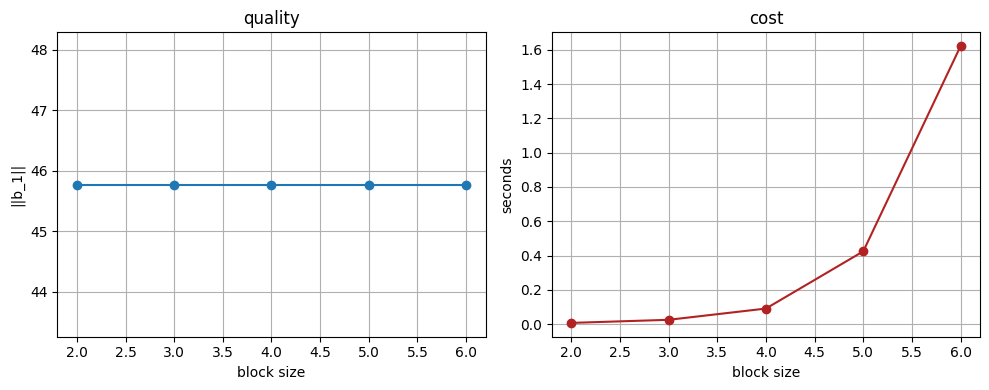

In [2]:
rng = np.random.default_rng(0)
B_seed = rng.integers(-40, 40, (8, 8)).astype(np.int64)
while abs(np.linalg.det(B_seed)) < 1.0:
    B_seed = rng.integers(-40, 40, (8, 8)).astype(np.int64)

blocks = [2, 3, 4, 5, 6]
lengths = []
times = []
for bs in blocks:
    t0 = time.time()
    R = bkz_reduce(B_seed.copy(), block_size=bs)
    times.append(time.time() - t0)
    lengths.append(float(np.linalg.norm(R[0])))
    print(f'block_size={bs}   ||b_1||={lengths[-1]:8.2f}   time={times[-1]:5.2f}s')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(blocks, lengths, 'o-'); axes[0].set_xlabel('block size'); axes[0].set_ylabel('||b_1||'); axes[0].set_title('quality')
axes[1].plot(blocks, times, 'o-', color='firebrick'); axes[1].set_xlabel('block size'); axes[1].set_ylabel('seconds'); axes[1].set_title('cost')
for ax in axes: ax.grid(True)
plt.tight_layout(); plt.show()

## LWE 공격에 이것이 중요한 이유

LWE의 비밀 $(s, e)$는 다음 노트북에서 만들 "primal 격자"의 짧은 벡터에 대응합니다. BKZ가 충분히 짧은 벡터를 복원할 수 있다면 비밀이 그대로 튀어나옵니다. 필요한 block size는 LWE 차원이 커질수록 커집니다 — 이것이 ML-KEM 파라미터 선택을 위한 비용 추정의 핵심입니다.

## Enumeration: block 내부

각 block 안에서 우리는 block의 기저 벡터들의 정수 조합 중 0이 아닌 가장 짧은 벡터를 찾습니다. 우리 `svp_enumerate`는 계수 범위 $[-c, c]$를 점진적으로 넓혀 가는 iterative deepening 방식을 씁니다. Schnorr-Euchner enumeration(GSO 노름에 의한 pruning 포함)이 더 빠르지만 읽기는 어렵습니다. 둘 다 같은 벡터를 찾습니다.

In [3]:
B_small = np.array([[3, 1, 0], [1, 3, 1], [0, 1, 3]], dtype=np.int64)
v = svp_enumerate(B_small)
print('shortest vector:', v)
print('norm^2:', int(np.dot(v, v)))

shortest vector: [-2  1 -2]
norm^2: 9


## 정리

- BKZ-$\beta$ 품질은 $\beta$가 커질수록 좋아집니다. 우리 순수 Python은 $\beta = 6$ 언저리가 한계입니다.
- 실전 공격은 fpylll을 통해 $\beta = 40$–$80$ 이상을 씁니다. Python/Rust/C++ 구현 간 격차는 약 3자릿수에 달합니다.
- ML-KEM 파라미터는 **알려진 최고 BKZ 공격**이 $2^{140}$ 이상의 연산을 요구하도록 선택되었습니다 — 노트북 19 참고.

→ `18_primal_attack_on_lwe.ipynb`